# DJIA Stock Returns Analysis

Scrape the 30 DJIA constituent tickers from Wikipedia, download 5 years of daily prices from Yahoo Finance, and analyse risk and return. We also include SPY (the S&P 500 ETF) as a benchmark.

**R original used:** tidyquant, rvest, purrr, lubridate, ggrepel, plotly  
**Python equivalents:** yfinance, pandas, seaborn, matplotlib

In [ ]:
# --- Import libraries ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import date, timedelta
from dateutil.relativedelta import relativedelta
import yfinance as yf

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# --- Scrape DJIA ticker symbols from Wikipedia ---
# pandas.read_html() is the Python equivalent of rvest::html_nodes('table')

import requests
from io import StringIO

headers = {"User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36"}
djia_url = 'https://en.wikipedia.org/wiki/Dow_Jones_Industrial_Average'

response = requests.get(djia_url, headers=headers)
response.raise_for_status()

tables = pd.read_html(StringIO(response.text))

table1 = tables[1].copy()
print('Columns:', table1.columns.tolist())
table1.head()

Columns: ['Company', 'Exchange', 'Symbol', 'Sector', 'Date added', 'Notes', 'Index weighting']


,Company,Exchange,Symbol,Sector,Date added,Notes,Index weighting
0,3M,NYSE,MMM,Industrials,1976-08-09,As Minnesota Mining and Manufacturing,2.17%
1,American Express,NYSE,AXP,Financials,1982-08-30,NaN,4.31%
2,Amgen,NASDAQ,AMGN,Health Care,2020-08-31,NaN,4.14%
3,Amazon,NASDAQ,AMZN,Consumer Discretionary,2024-02-26,NaN,2.99%
4,Apple,NASDAQ,AAPL,Information Technology,2015-03-19,NaN,2.92%


In [7]:
# --- Extract clean ticker symbols ---
# Wikipedia lists symbols as 'NYSE: MMM' for NYSE-listed stocks
# Yahoo Finance just needs the ticker part (e.g. 'MMM')

def clean_ticker(symbol_str):
    """Strip exchange prefix (e.g. 'NYSE: MMM' -> 'MMM')."""
    if isinstance(symbol_str, str) and ':' in symbol_str:
        return symbol_str.split(':')[-1].strip()
    return str(symbol_str).strip()

# Find the column containing ticker symbols (it usually contains ':' for NYSE listings)
ticker_col = [c for c in table1.columns if table1[c].astype(str).str.contains(':').any()]
ticker_col = ticker_col[0] if ticker_col else 'Symbol'

tickers = (
    table1[ticker_col]
    .apply(clean_ticker)
    .dropna()
    .unique()
    .tolist()
)

# Add SPY as a benchmark (tracks the S&P 500)
tickers = tickers + ['SPY']
print(f'Total tickers to download: {len(tickers)}')
print(tickers)

Total tickers to download: 31
['MMM', 'AXP', 'AMGN', 'AMZN', 'AAPL', 'BA', 'CAT', 'CVX', 'CSCO', 'KO', 'DIS', 'GS', 'HD', 'HON', 'IBM', 'JNJ', 'JPM', 'MCD', 'MRK', 'MSFT', 'NKE', 'NVDA', 'PG', 'CRM', 'SHW', 'TRV', 'UNH', 'VZ', 'V', 'WMT', 'SPY']


In [8]:
# --- Define date range: 5 years back from today ---
end_date   = date.today()
start_date = end_date - relativedelta(years=5)
start_date = date(start_date.year, 1, 1)   # snap to Jan 1 of that year

print(f'Download period: {start_date} to {end_date}')

Download period: 2021-01-01 to 2026-03-20


In [9]:
# --- Download adjusted closing prices from Yahoo Finance ---
# yf.download() with multiple tickers returns a multi-level DataFrame
# We stack it into a long 'tidy' format: date | symbol | adjusted

raw = yf.download(
    tickers,
    start=str(start_date),
    end=str(end_date),
    auto_adjust=True,     # adjusted for splits and dividends
    progress=False
)

# Keep only the 'Close' column (= adjusted close when auto_adjust=True)
my_stocks = (
    raw['Close']
    .stack()                               # wide → long
    .reset_index()
    .rename(columns={'level_1': 'symbol', 0: 'adjusted', 'Ticker': 'symbol'})
    .dropna(subset=['adjusted'])
    .sort_values(['symbol', 'Date'])
    .rename(columns={'Date': 'date'})
)

print('my_stocks shape:', my_stocks.shape)
my_stocks.head()

my_stocks shape: (40548, 3)


,date,symbol,adjusted
0,2021-01-04,AAPL,125.856705
31,2021-01-05,AAPL,127.412743
62,2021-01-06,AAPL,123.123840
93,2021-01-07,AAPL,127.325241
124,2021-01-08,AAPL,128.424225


In [10]:
# --- Calculate daily log returns ---
# Equivalent to tq_transmute(mutate_fun=periodReturn, period='daily', type='log')
# Log returns are additive over time and approximately normally distributed

daily_returns = (
    my_stocks
    .sort_values(['symbol', 'date'])
    .assign(
        daily_returns=lambda df: df.groupby('symbol')['adjusted']
                                   .transform(lambda x: np.log(x / x.shift(1)))
    )
    .dropna(subset=['daily_returns'])
    [['date', 'symbol', 'daily_returns']]
)

print('Daily returns shape:', daily_returns.shape)
daily_returns.head()

Daily returns shape: (40517, 3)


,date,symbol,daily_returns
31,2021-01-05,AAPL,0.012288
62,2021-01-06,AAPL,-0.034241
93,2021-01-07,AAPL,0.033554
124,2021-01-08,AAPL,0.008594
155,2021-01-11,AAPL,-0.023524


In [11]:
# --- Calculate monthly arithmetic returns ---
# We resample to month-end, then compute simple % change

monthly_returns = (
    my_stocks
    .assign(date=lambda df: pd.to_datetime(df['date']))
    .set_index('date')
    .groupby('symbol')['adjusted']
    .resample('ME')          # resample to month-end frequency
    .last()                  # take the last adjusted price of the month
    .reset_index()
    .sort_values(['symbol', 'date'])
    .assign(
        monthly_returns=lambda df: df.groupby('symbol')['adjusted']
                                     .pct_change()     # simple % change month-over-month
    )
    .dropna(subset=['monthly_returns'])
    [['date', 'symbol', 'monthly_returns']]
)

print('Monthly returns shape:', monthly_returns.shape)
monthly_returns.head()

Monthly returns shape: (1922, 3)


,date,symbol,monthly_returns
1,2021-02-28,AAPL,-0.079712
2,2021-03-31,AAPL,0.007340
3,2021-04-30,AAPL,0.076218
4,2021-05-31,AAPL,-0.050497
5,2021-06-30,AAPL,0.099109


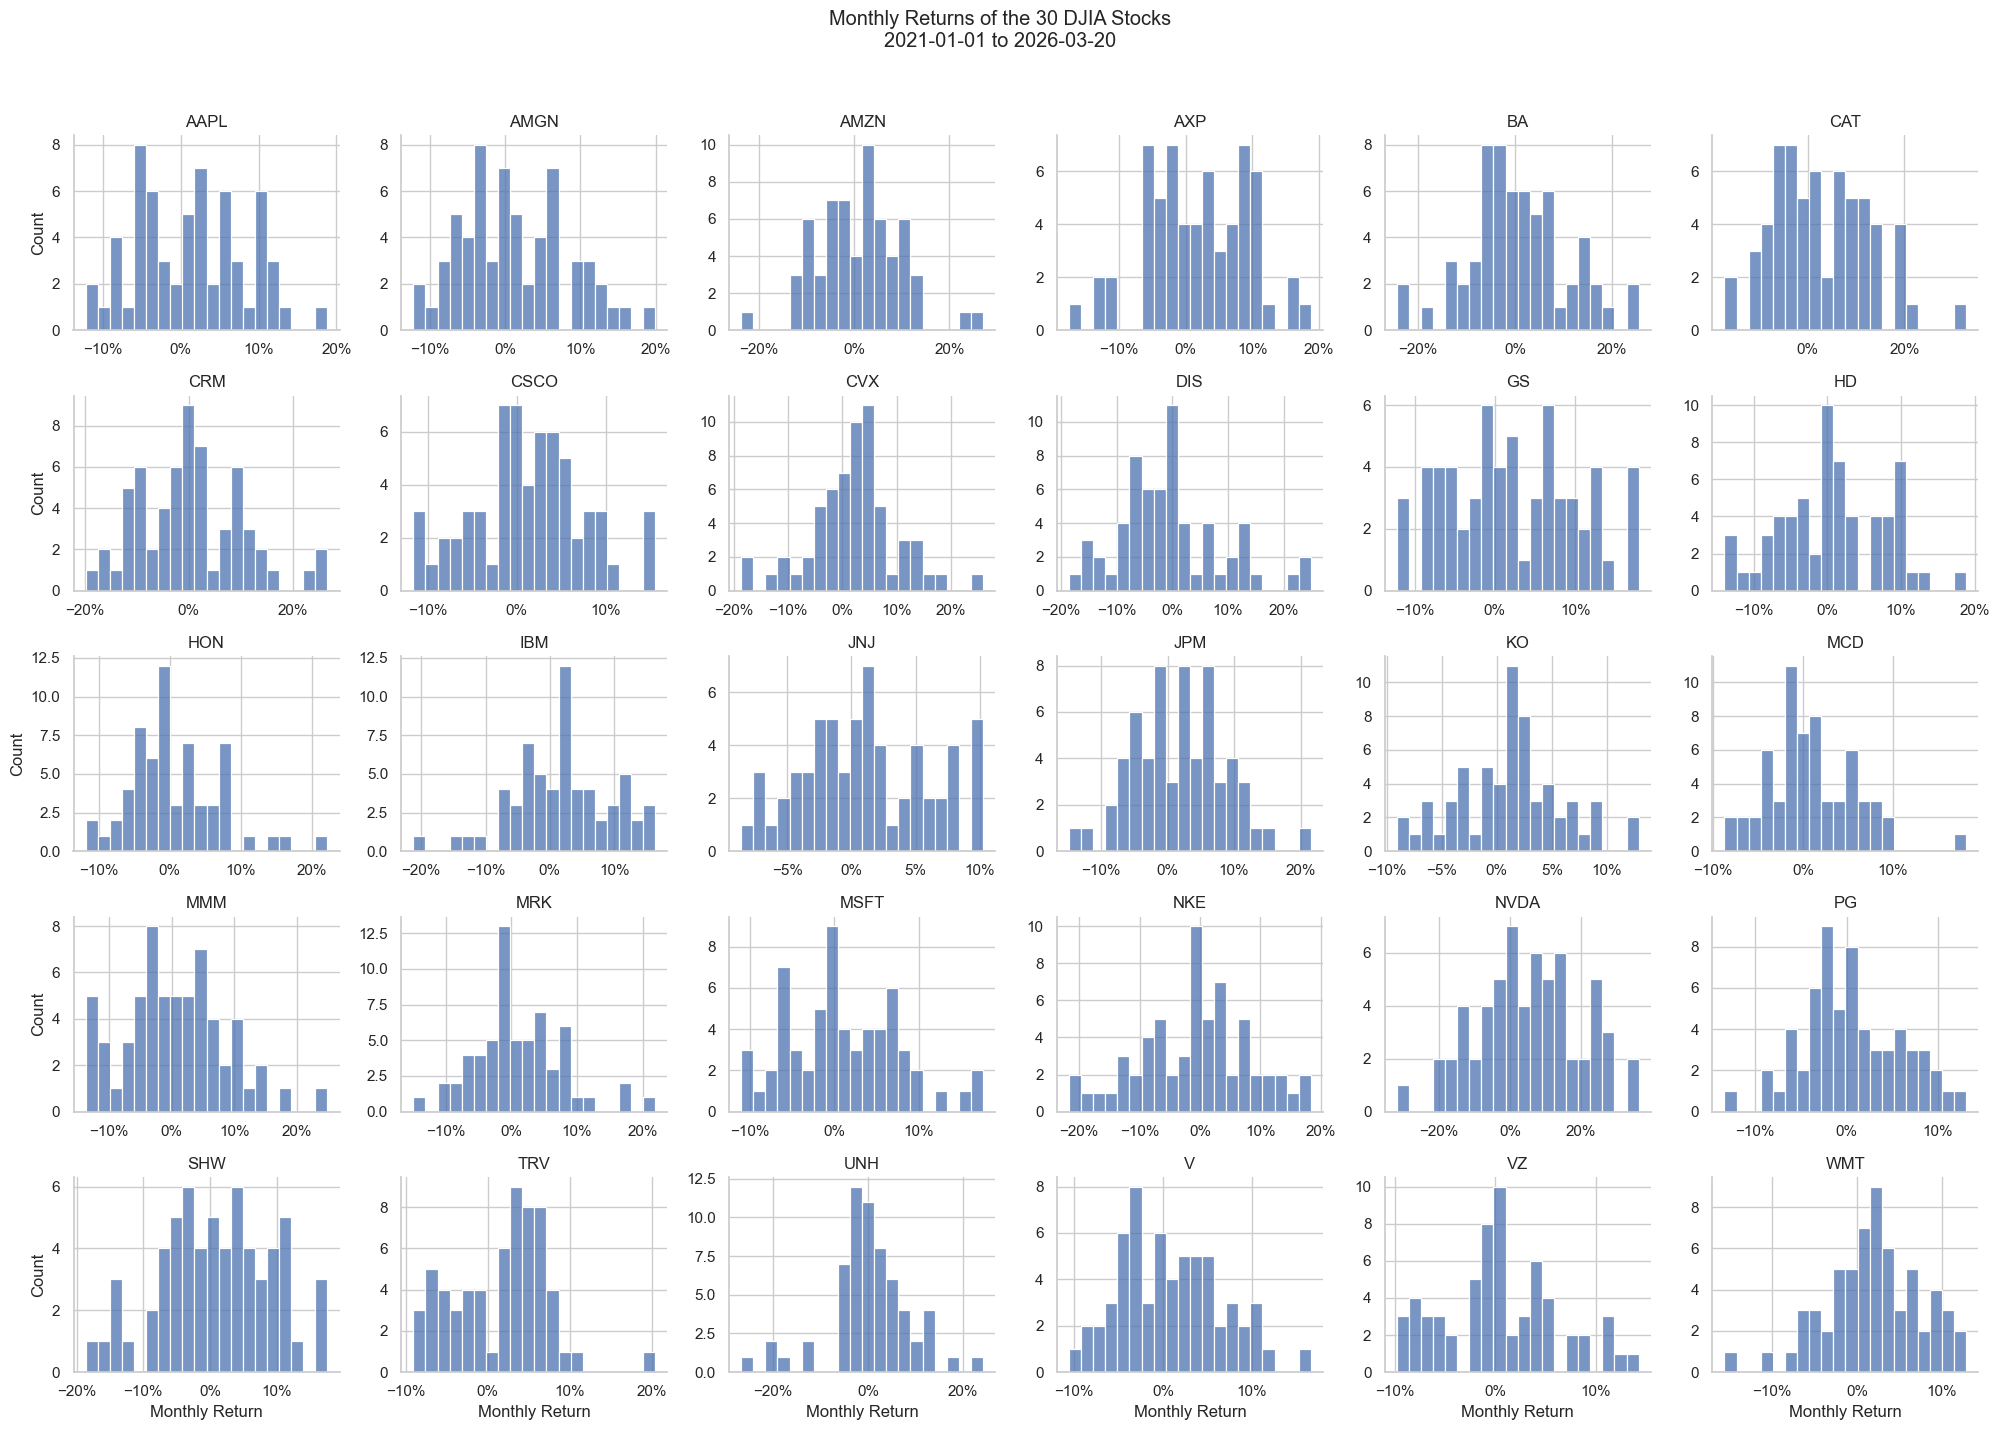

In [12]:
# --- Histogram of monthly returns, faceted by stock ---
# Exclude SPY so we see only the 30 DJIA components

plot_data = monthly_returns[monthly_returns['symbol'] != 'SPY']

g = sns.FacetGrid(
    plot_data,
    col='symbol',
    col_wrap=6,
    sharey=False, sharex=False,
    height=2.8, aspect=1.2
)
g.map(sns.histplot, 'monthly_returns', bins=20, kde=False)
g.set_axis_labels('Monthly Return', 'Count')
g.set_titles('{col_name}')

# Format x-axis ticks as percentages
for ax in g.axes.flatten():
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

g.figure.suptitle(
    f'Monthly Returns of the 30 DJIA Stocks\n{start_date} to {end_date}',
    y=1.02
)
plt.tight_layout()
plt.show()

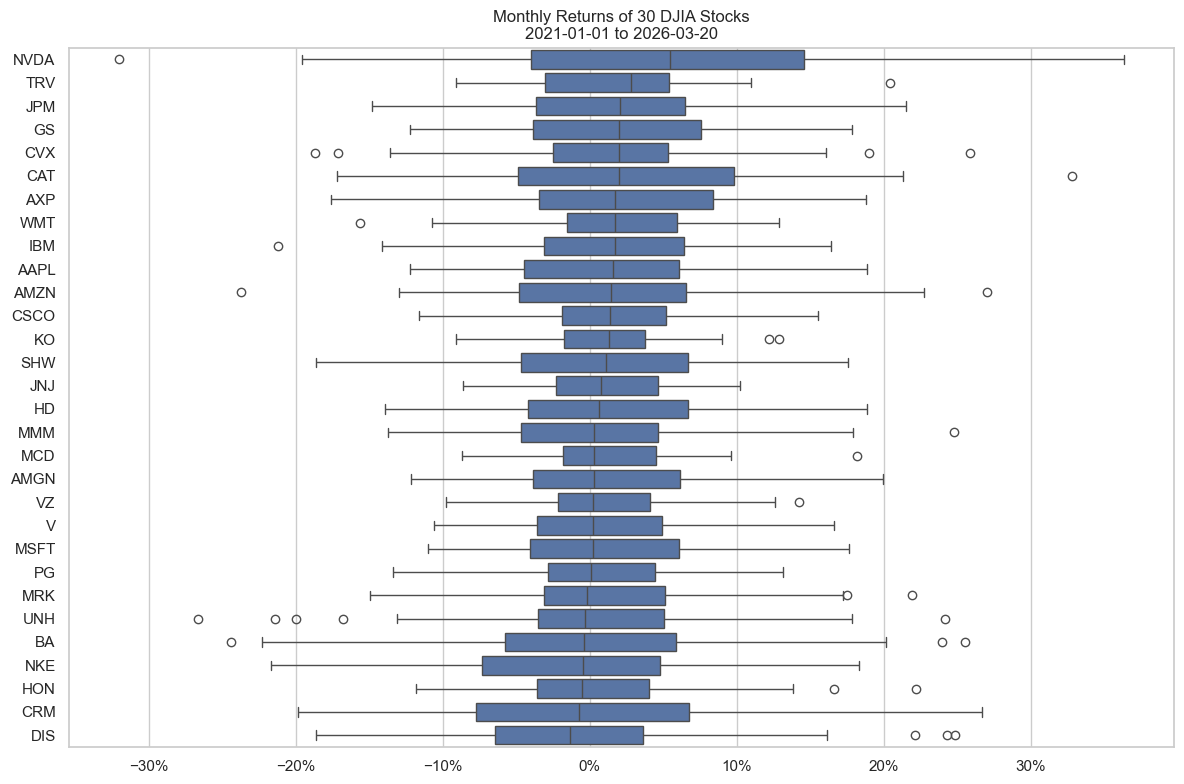

In [14]:
# --- Boxplot: monthly returns, stocks ordered by median return ---
# We replicate this by computing the median per stock and sorting

median_order = (
    plot_data
    .groupby('symbol')['monthly_returns']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(12, 8))
sns.boxplot(
    data=plot_data,
    x='monthly_returns',
    y='symbol',
    order=median_order,    # sorted by median (ascending)
    ax=ax
)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title(f'Monthly Returns of 30 DJIA Stocks\n{start_date} to {end_date}')
plt.tight_layout()
plt.show()

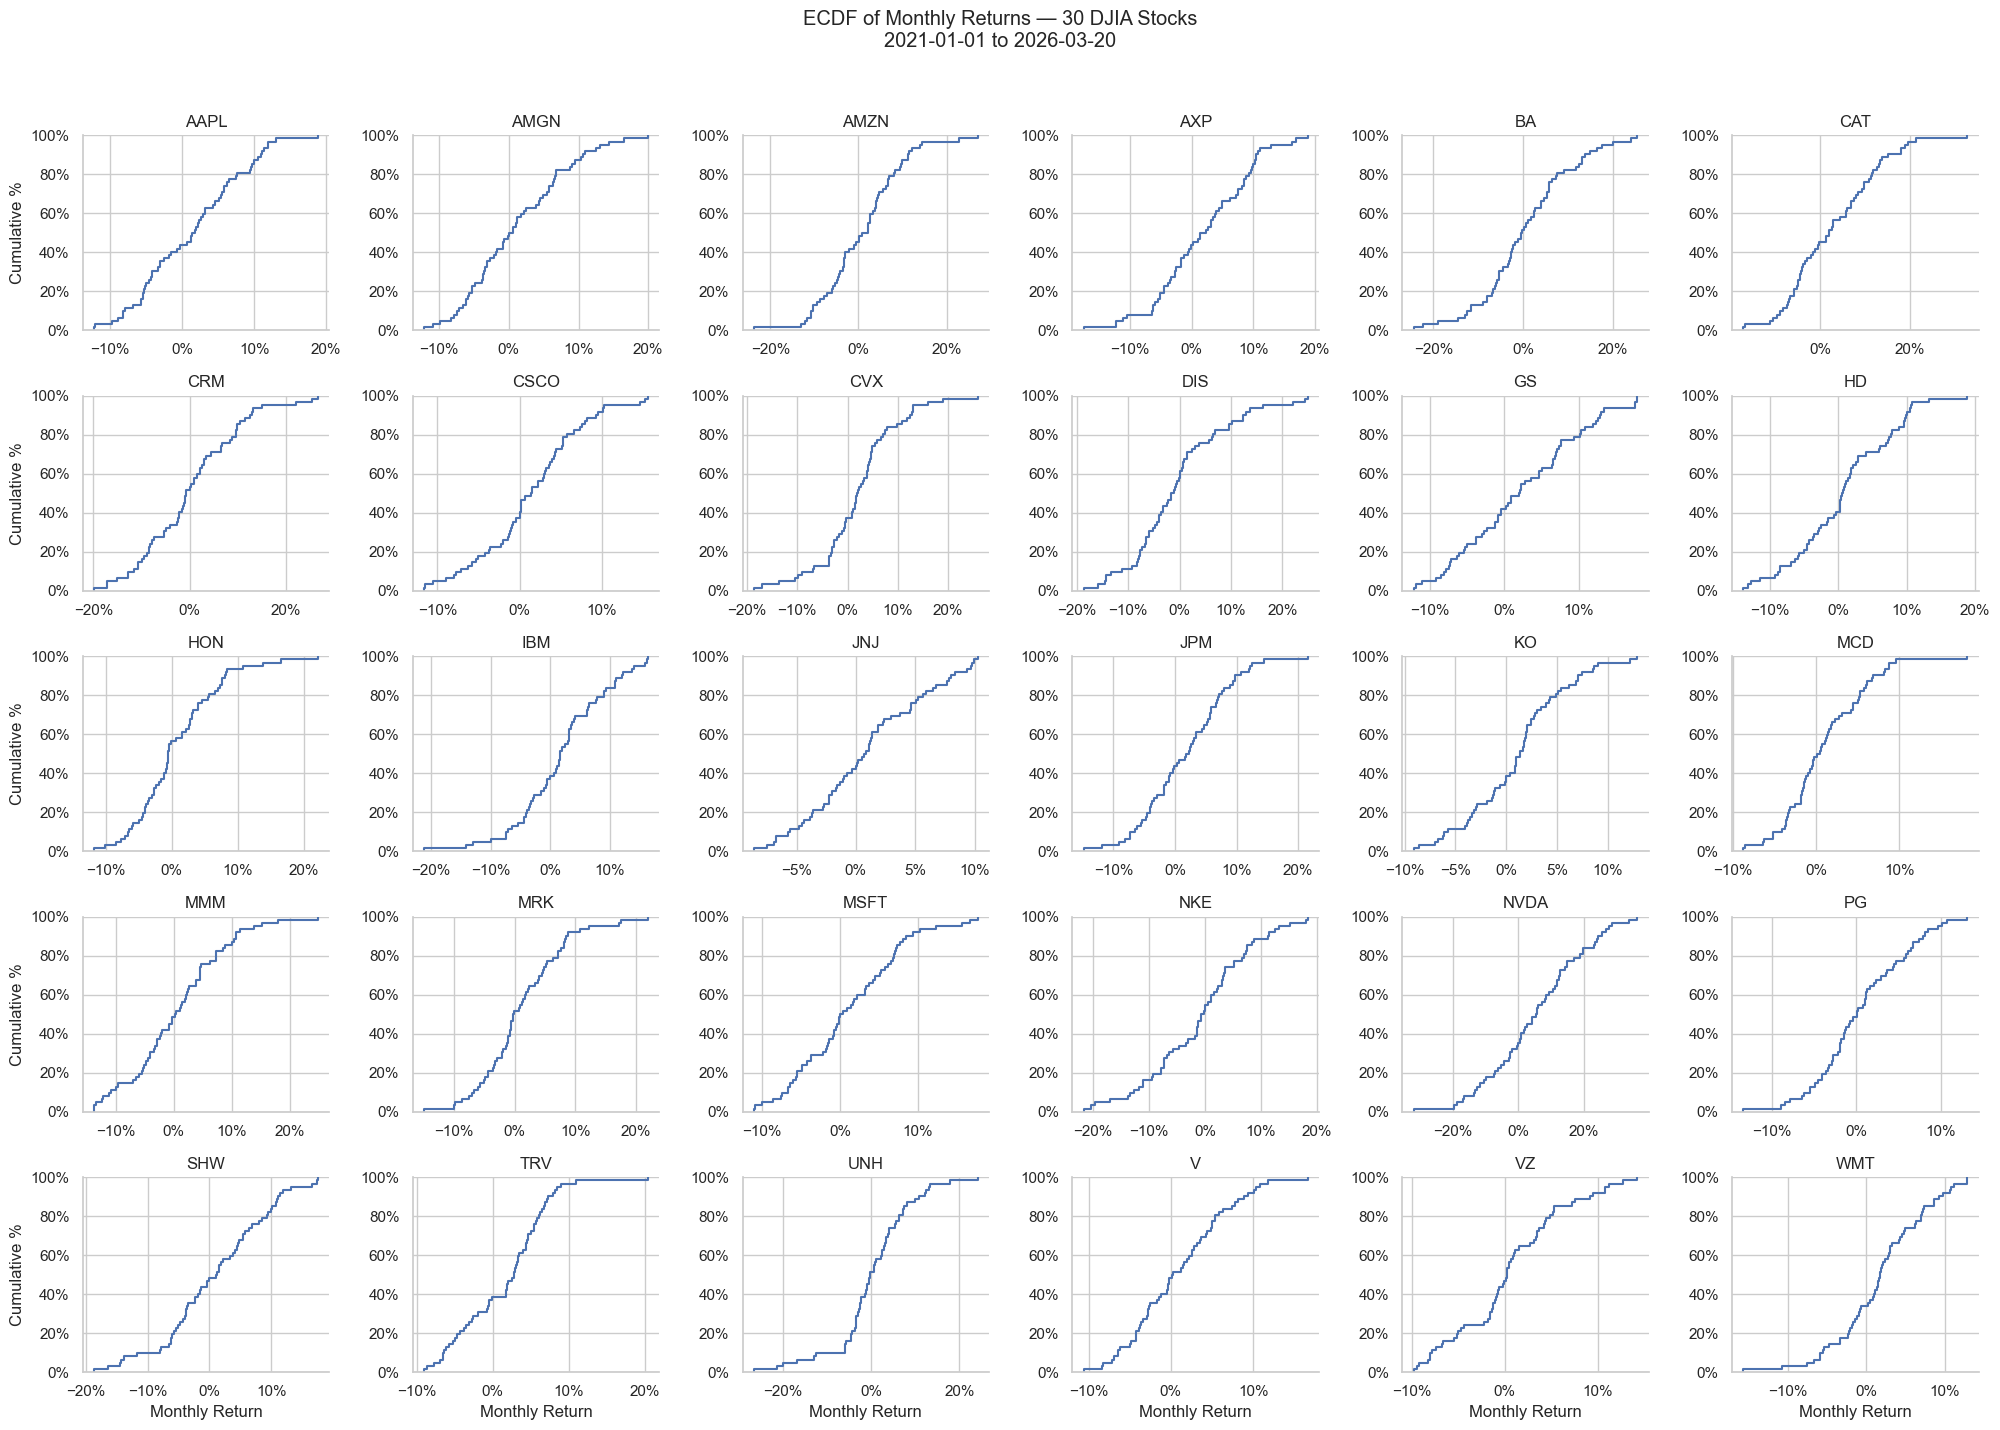

In [15]:
# --- ECDF of monthly returns, faceted by stock ---

g = sns.FacetGrid(
    plot_data,
    col='symbol',
    col_wrap=6,
    sharey=False, sharex=False,
    height=2.8, aspect=1.2
)
g.map(sns.ecdfplot, 'monthly_returns')
g.set_axis_labels('Monthly Return', 'Cumulative %')
g.set_titles('{col_name}')

for ax in g.axes.flatten():
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

g.figure.suptitle(
    f'ECDF of Monthly Returns — 30 DJIA Stocks\n{start_date} to {end_date}',
    y=1.02
)
plt.tight_layout()
plt.show()

In [16]:
# --- Summary table: mean, SD, 95% CI per stock ---

from scipy import stats as scipy_stats

monthly_summaries = (
    monthly_returns
    .groupby('symbol')['monthly_returns']
    .agg(
        count='count',
        mean_return='mean',
        sd_return='std',
        min_return='min',
        max_return='max'
    )
    .assign(
        se_return=lambda df: df['sd_return'] / np.sqrt(df['count']),
        # t-critical value for a two-tailed 95% interval
        t_crit=lambda df: df['count'].apply(lambda n: scipy_stats.t.ppf(0.975, df=n-1)),
    )
    .assign(
        lower_95=lambda df: df['mean_return'] - df['t_crit'] * df['se_return'],
        upper_95=lambda df: df['mean_return'] + df['t_crit'] * df['se_return'],
    )
    .sort_values('mean_return', ascending=False)
    .round(4)
)

print('Summary statistics per stock (top 10 by mean return):')
monthly_summaries.head(10)

Summary statistics per stock (top 10 by mean return):


,count,mean_return,sd_return,min_return,max_return,se_return,t_crit,lower_95,upper_95
symbol,,,,,,,,,
NVDA,62,0.0533,0.1450,-0.3203,0.3634,0.0184,1.9996,0.0165,0.0901
CAT,62,0.0279,0.1001,-0.1718,0.3281,0.0127,1.9996,0.0024,0.0533
GS,62,0.0229,0.0802,-0.1221,0.1787,0.0102,1.9996,0.0025,0.0433
CVX,62,0.0207,0.0796,-0.1867,0.2591,0.0101,1.9996,0.0005,0.0409
IBM,62,0.0191,0.0762,-0.2123,0.1640,0.0097,1.9996,-0.0002,0.0385
AXP,62,0.0190,0.0770,-0.1758,0.1881,0.0098,1.9996,-0.0005,0.0386
WMT,62,0.0182,0.0571,-0.1562,0.1287,0.0072,1.9996,0.0037,0.0327
JPM,62,0.0175,0.0691,-0.1484,0.2154,0.0088,1.9996,-0.0001,0.0350
TRV,62,0.0159,0.0566,-0.0907,0.2040,0.0072,1.9996,0.0015,0.0303


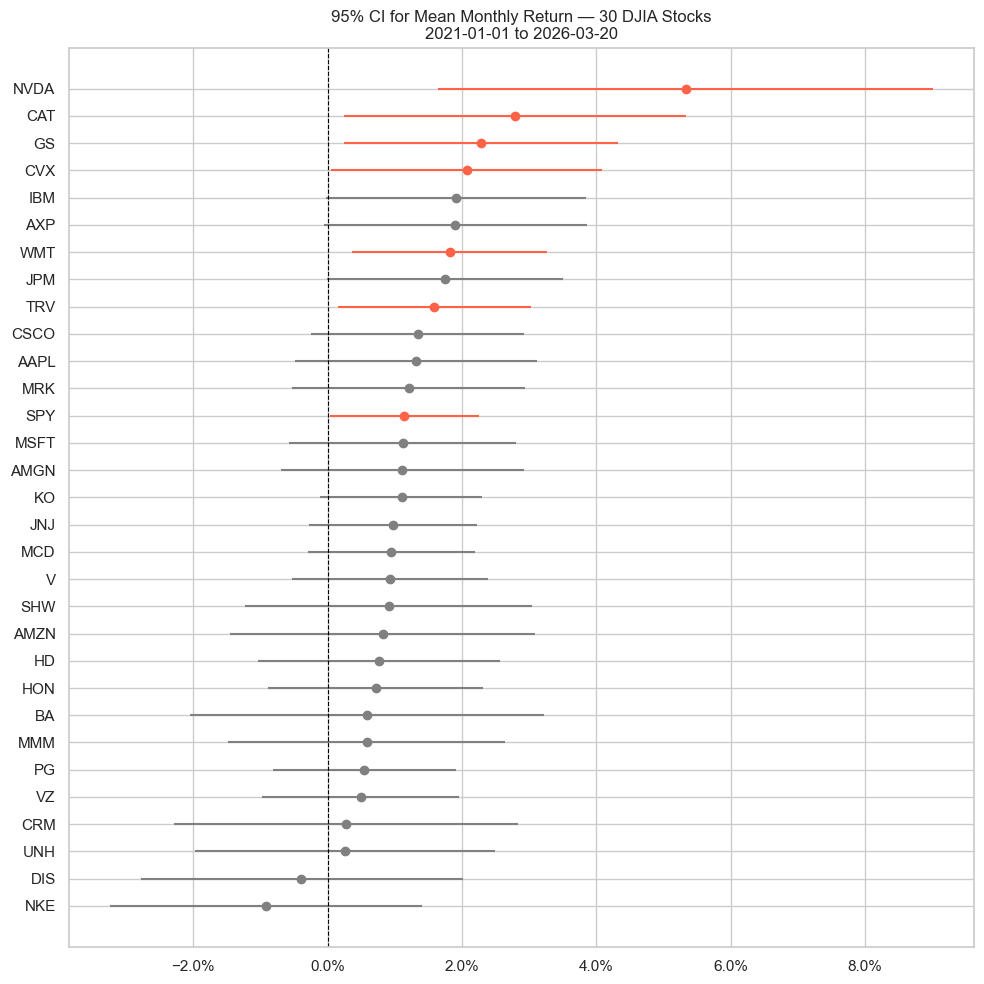

In [17]:
# --- 95% CI dot-and-whisker plot ---
# Stocks whose CI crosses zero are coloured grey; those entirely above zero are tomato

ci_data = (
    monthly_summaries
    .reset_index()
    .assign(
        contains_zero=lambda df: df['lower_95'] < 0   # True if CI includes zero
    )
    .sort_values('mean_return')
)

fig, ax = plt.subplots(figsize=(10, 10))

for _, row in ci_data.iterrows():
    colour = 'grey' if row['contains_zero'] else 'tomato'
    ax.errorbar(
        x=row['mean_return'],
        y=row['symbol'],
        xerr=[[row['mean_return'] - row['lower_95']],
              [row['upper_95'] - row['mean_return']]],
        fmt='o',
        color=colour,
        markersize=6,
        linewidth=1.5
    )

ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title(f'95% CI for Mean Monthly Return — 30 DJIA Stocks\n{start_date} to {end_date}')
plt.tight_layout()
plt.show()

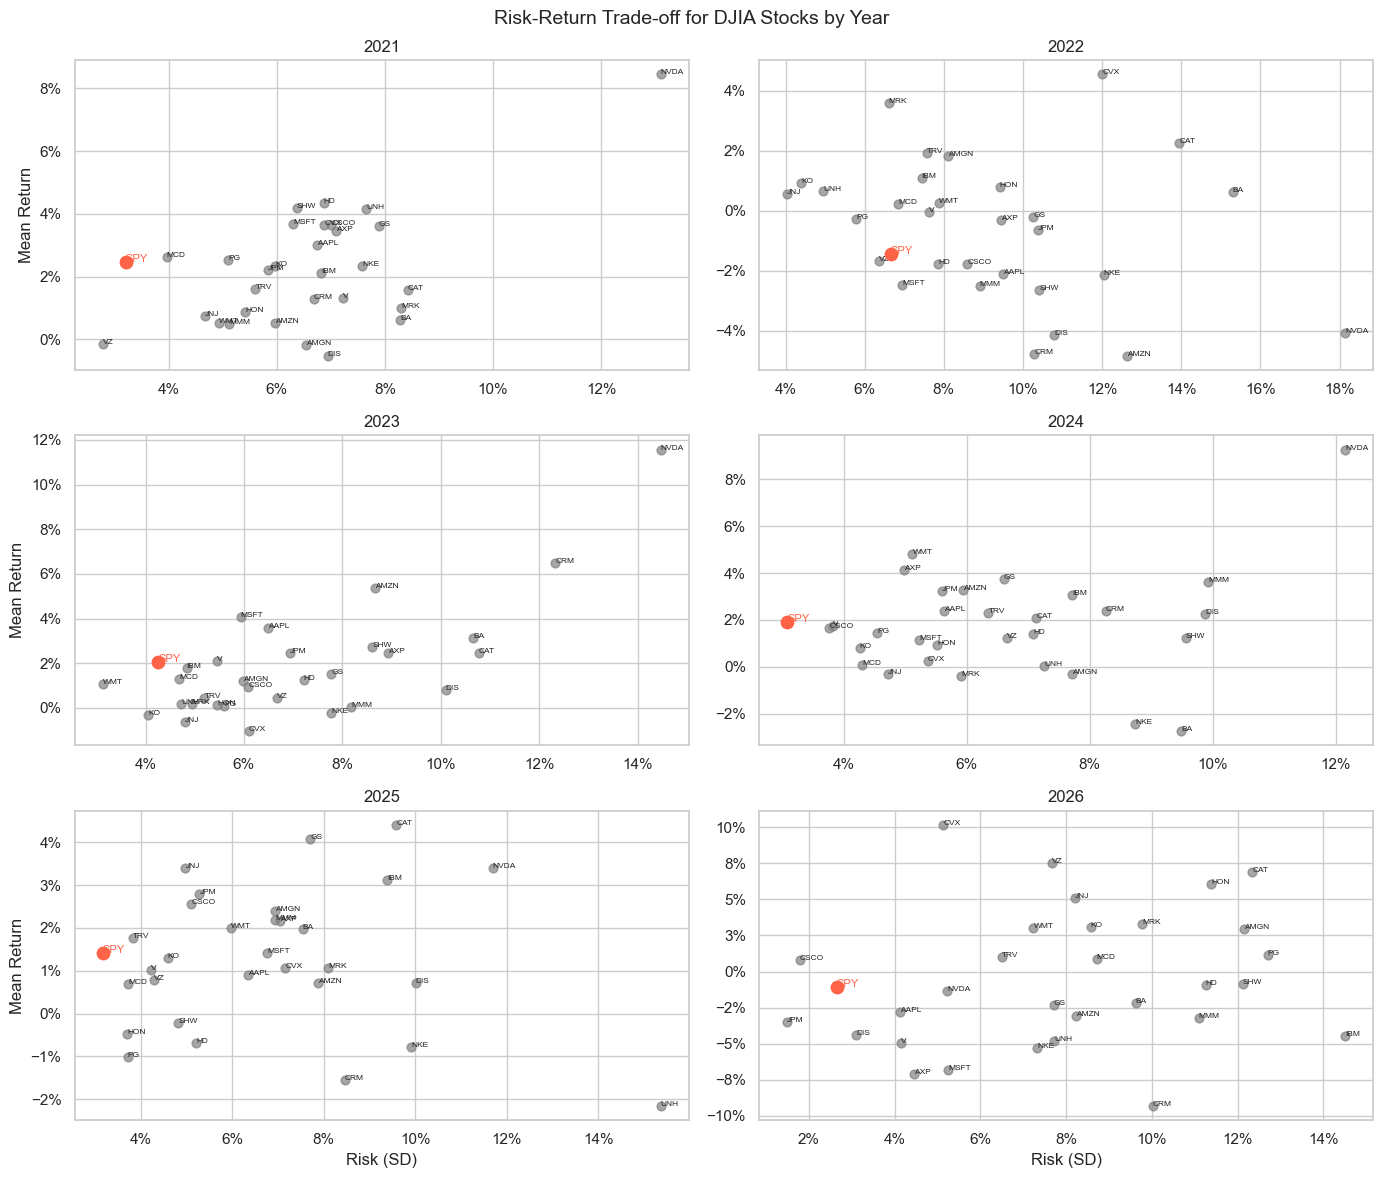

In [18]:
# --- Risk-Return scatter faceted by year ---
# Risk = SD of monthly returns; Return = mean monthly return
# Each point is one stock; SPY highlighted in tomato

by_year = (
    monthly_returns
    .assign(year=lambda df: df['date'].dt.year)
    .groupby(['year', 'symbol'])['monthly_returns']
    .agg(mean_return='mean', sd_return='std')
    .reset_index()
    .assign(is_spy=lambda df: df['symbol'] == 'SPY')
)

years = sorted(by_year['year'].unique())
n_years = len(years)
cols = 2
rows = (n_years + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
axes = axes.flatten()

for i, year in enumerate(years):
    ax   = axes[i]
    data = by_year[by_year['year'] == year]
    # Non-SPY stocks
    ax.scatter(
        data.loc[~data['is_spy'], 'sd_return'],
        data.loc[~data['is_spy'], 'mean_return'],
        color='grey', alpha=0.7, s=40
    )
    # Label each non-SPY stock
    for _, r in data[~data['is_spy']].iterrows():
        ax.text(r['sd_return'], r['mean_return'], r['symbol'], fontsize=6, ha='left')
    # SPY benchmark
    spy_row = data[data['is_spy']]
    if not spy_row.empty:
        ax.scatter(spy_row['sd_return'], spy_row['mean_return'],
                   color='tomato', s=80, zorder=5)
        ax.text(spy_row['sd_return'].iloc[0], spy_row['mean_return'].iloc[0],
                'SPY', fontsize=8, color='tomato', ha='left')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_title(str(year))
    ax.set_xlabel('Risk (SD)' if i >= (rows-1)*cols else '')
    ax.set_ylabel('Mean Return' if i % cols == 0 else '')

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Risk-Return Trade-off for DJIA Stocks by Year', fontsize=14)
plt.tight_layout()
plt.show()

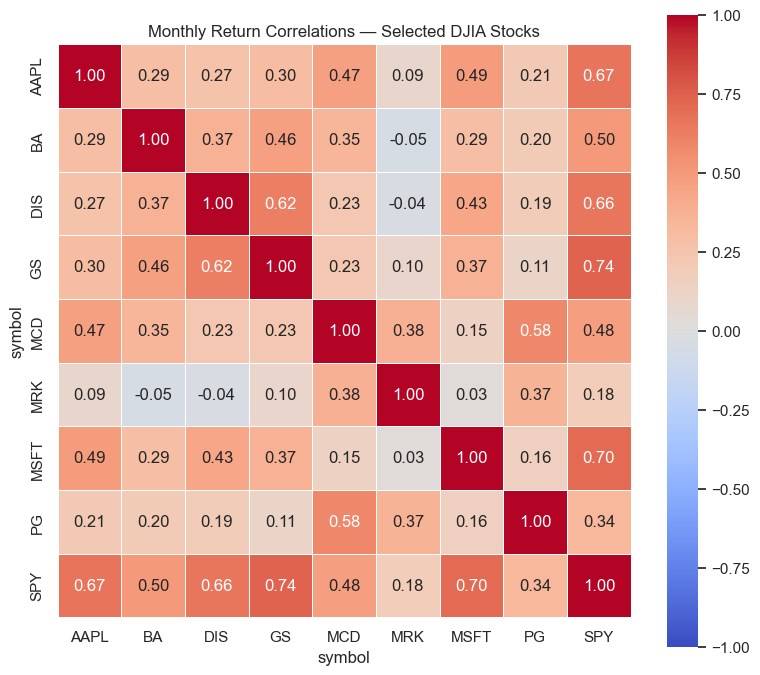

In [21]:
# --- Correlation-scatterplot matrix for selected stocks ---

selected = ['SPY', 'AAPL', 'BA', 'DIS', 'PG', 'GS', 'MCD', 'MRK', 'MSFT']

corr_pivot = (
    monthly_returns
    .loc[monthly_returns['symbol'].isin(selected)]
    .pivot_table(index='date', columns='symbol', values='monthly_returns')
    .dropna()
)

fig, ax = plt.subplots(figsize=(8, 7))

sns.heatmap(
    corr_pivot.corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    ax=ax
)

ax.set_title('Monthly Return Correlations — Selected DJIA Stocks')
plt.tight_layout()
plt.show()

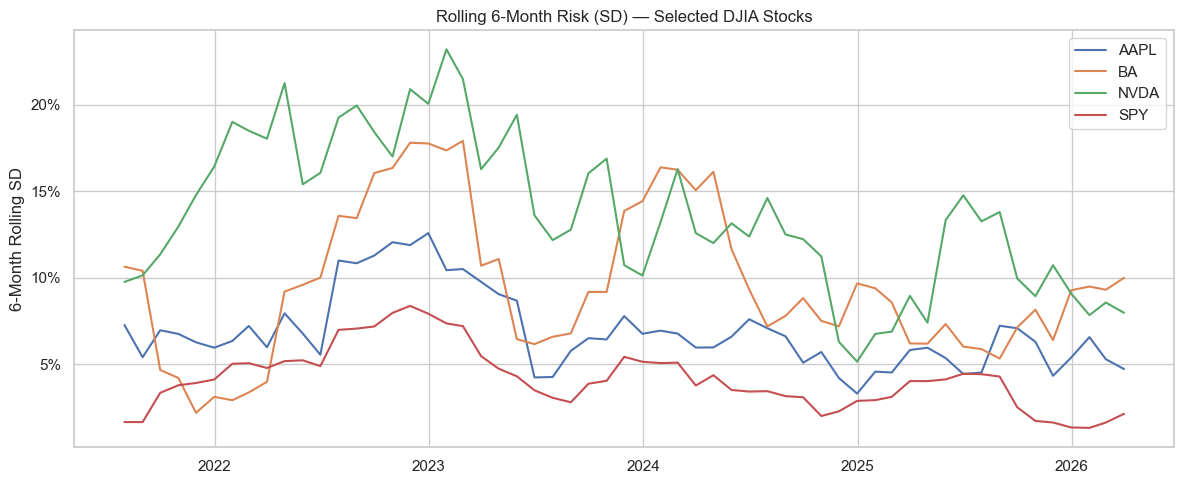

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=rolling_sd,
    x='date', y='rolling_sd',
    hue='symbol',
    ax=ax
)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel('')
ax.set_ylabel('6-Month Rolling SD')
ax.legend(title='')
ax.set_title('Rolling 6-Month Risk (SD) — Selected DJIA Stocks')
plt.tight_layout()
plt.show()

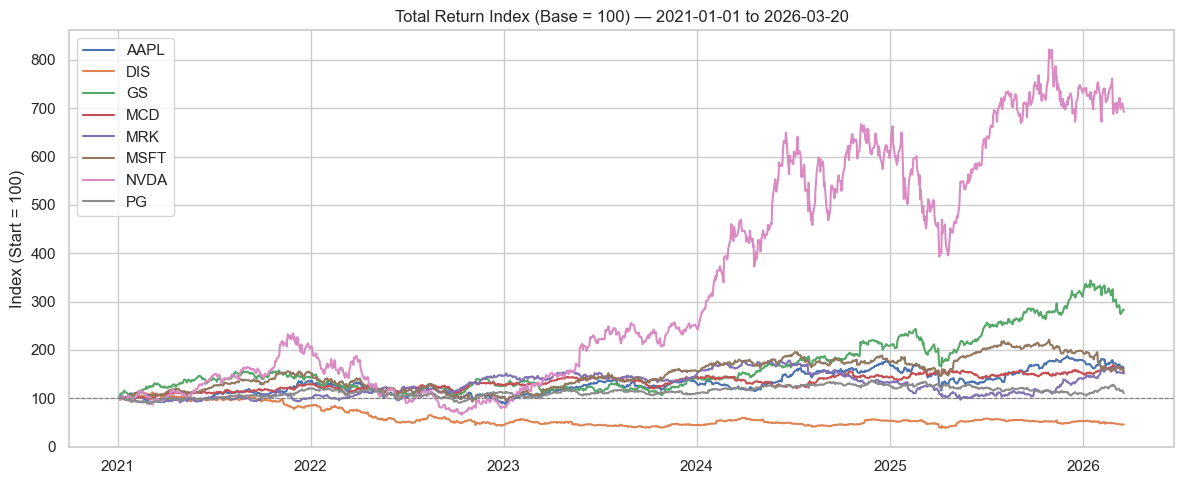

In [26]:
# --- Total return index: growth of $100 invested ---
# Equivalent to cumprod(1 + daily_returns) scaled to $100

selected_tr = ['AAPL', 'MSFT', 'GS', 'PG', 'MCD', 'MRK', 'DIS', 'NVDA']

total_returns_norm = (
    daily_returns
    .loc[daily_returns['symbol'].isin(selected_tr)]
    .sort_values(['symbol', 'date'])
    .assign(
        total_return=lambda df: df.groupby('symbol')['daily_returns']
                                   .transform(lambda x: 100 * (1 + x).cumprod())
    )
)

fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=total_returns_norm,
    x='date', y='total_return',
    hue='symbol',
    ax=ax
)

ax.axhline(100, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('')
ax.set_ylabel('Index (Start = 100)')
ax.legend(title='')
ax.set_title(f'Total Return Index (Base = 100) — {start_date} to {end_date}')
plt.tight_layout()
plt.show()